# UAV / Drone Detection & Tracking  
## YOLOv8 + Kalman Filter  |  Google Colab  

**Pipeline:**

1. Mount Google Drive & install dependencies  
2. Load final trained YOLOv8 model (50 epochs, early stopping at best epoch)  
3. Evaluate model on Validation & Test sets — Precision, Recall, mAP@50, mAP@50–95, F1  
4. Visualize detection results on unseen test images  
5. Construct temporally ordered frame sequences (Drone 2 / Drone 3)  
6. Apply Kalman filter–based multi-object tracking (IoU + center-distance association)  
7. Generate tracking visualizations (annotated frames + MP4 video)  
8. Plot UAV trajectories for motion analysis  
9. Save all outputs (metrics, video, trajectories) to Google Drive  

---
## Mount Google Drive & Install Dependencies

In [1]:
# ─────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Install required packages
import subprocess
subprocess.run(['pip', 'install', '-q', 'ultralytics', 'supervision',
                'seaborn', 'matplotlib', 'opencv-python-headless'], check=True)

print("Dependencies installed.")

Mounted at /content/drive
Dependencies installed.


---
## Imports

In [2]:
!pip install ultralytics -q

import os, glob, re, shutil, cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from IPython.display import Video, display
from ultralytics import YOLO

WORK_DIR = "/content/uav_project"
os.makedirs(WORK_DIR, exist_ok=True)

DATA_YAML = "/content/drive/MyDrive/New_Global_Split_v2/data.yaml"
BEST_PT = "/content/drive/MyDrive/YOLO_Models/uav_yolov8n_ep50_optimized/best.pt"

device = 0  # use GPU
IMG_SIZE = 640
BATCH = 8

CLASS_NAMES = {0: "drone"}

assert os.path.exists(BEST_PT), "Saved model not found."
assert os.path.exists(DATA_YAML), "data.yaml not found."

model = YOLO(BEST_PT)
print("Final model loaded:", BEST_PT)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Final model loaded: /content/drive/MyDrive/YOLO_Models/uav_yolov8n_ep50_optimized/best.pt


---
## Evaluate final model

In [3]:
def print_metrics(name, results):
    mp = results.box.mp
    mr = results.box.mr
    map50 = results.box.map50
    map95 = results.box.map
    f1 = 2 * mp * mr / (mp + mr + 1e-9)

    print(f"\n📊 {name} Metrics")
    print(f"Precision : {mp:.4f}")
    print(f"Recall    : {mr:.4f}")
    print(f"mAP@0.50  : {map50:.4f}")
    print(f"mAP@50-95 : {map95:.4f}")
    print(f"F1 Score  : {f1:.4f}")

In [5]:
device = 'cpu'

val_results = model.val(
    data=DATA_YAML,
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    conf=0.25,
    iou=0.45,
    plots=True,
    project=WORK_DIR,
    name="val_final",
    exist_ok=True
)

test_results = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    conf=0.25,
    iou=0.45,
    plots=True,
    project=WORK_DIR,
    name="test_final",
    exist_ok=True
)

print_metrics("Validation", val_results)
print_metrics("Test", test_results)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 3.9±1.6 ms, read: 0.2±0.1 MB/s, size: 105.3 KB)
val: Scanning /content/drive/MyDrive/New_Global_Split_v2/val/labels.cache... 1050 images, 395 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1050/1050 122.3Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 46, len(boxes) = 701. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 2.9s/it 6:22
                   all       1050        701      0.922      0.816      0.813      0.439
Speed: 4.6ms preprocess, 280.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /con

---
## Metrics Visualization Dashboard

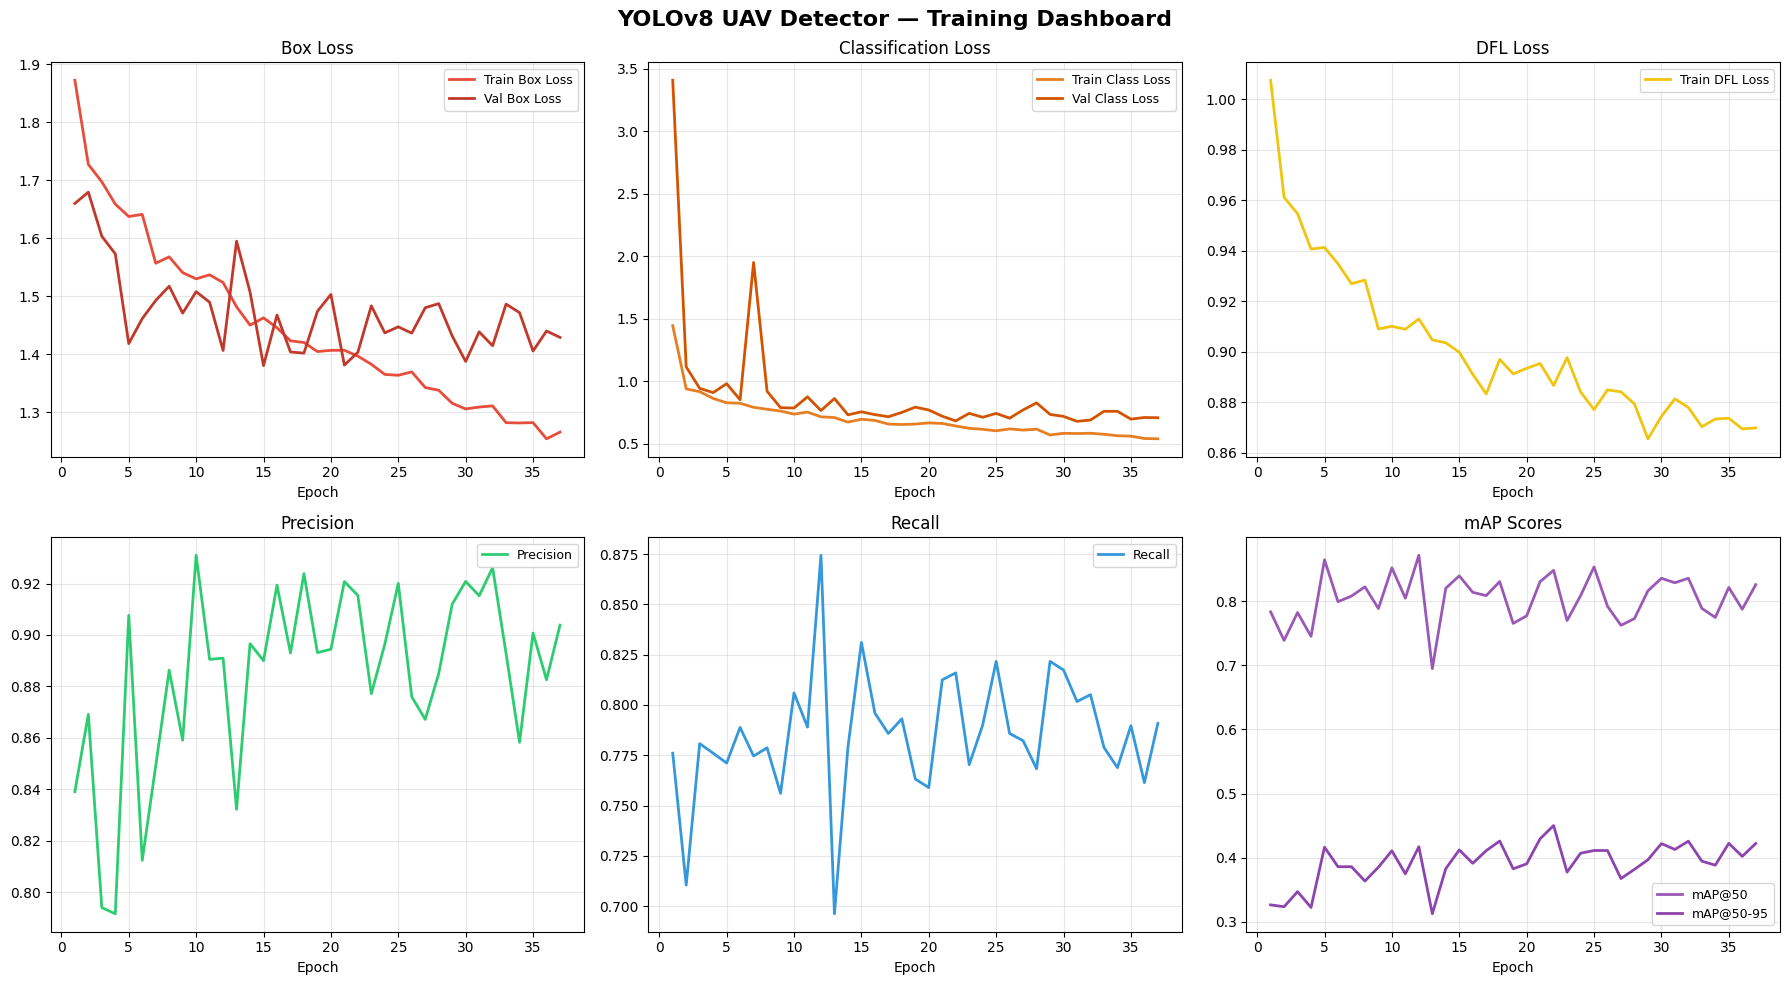

Dashboard saved: /content/uav_project/training_dashboard.png


In [6]:
# ─────────────────────────────────────────────
def load_training_csv(train_dir):
    csv_path = os.path.join(train_dir, 'results.csv')
    if not os.path.isfile(csv_path):
        return None
    import pandas as pd
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    return df

# Path to saved training results
TRAIN_RESULTS_DIR = "/content/drive/MyDrive/YOLO_Models/uav_yolov8n_ep50_optimized/train_results"

try:
    import pandas as pd

    df = load_training_csv(TRAIN_RESULTS_DIR)

    if df is not None:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('YOLOv8 UAV Detector — Training Dashboard', fontsize=16, fontweight='bold')

        cols_map = {
            'train/box_loss': ('Train Box Loss',    axes[0, 0], '#E74C3C'),
            'train/cls_loss': ('Train Class Loss',  axes[0, 1], '#E67E22'),
            'train/dfl_loss': ('Train DFL Loss',    axes[0, 2], '#F1C40F'),
            'val/box_loss':   ('Val Box Loss',      axes[0, 0], '#C0392B'),
            'val/cls_loss':   ('Val Class Loss',    axes[0, 1], '#D35400'),
            'metrics/precision(B)': ('Precision',  axes[1, 0], '#2ECC71'),
            'metrics/recall(B)':    ('Recall',     axes[1, 1], '#3498DB'),
            'metrics/mAP50(B)':     ('mAP@50',     axes[1, 2], '#9B59B6'),
            'metrics/mAP50-95(B)':  ('mAP@50-95',  axes[1, 2], '#8E44AD'),
        }

        for col, (label, ax, color) in cols_map.items():
            if col in df.columns:
                ax.plot(df['epoch'], df[col], label=label, color=color, linewidth=2)
                ax.set_xlabel('Epoch')
                ax.legend(fontsize=9)
                ax.grid(True, alpha=0.3)

        axes[0, 0].set_title('Box Loss')
        axes[0, 1].set_title('Classification Loss')
        axes[0, 2].set_title('DFL Loss')
        axes[1, 0].set_title('Precision')
        axes[1, 1].set_title('Recall')
        axes[1, 2].set_title('mAP Scores')

        plt.tight_layout()

        dashboard_path = os.path.join(WORK_DIR, 'training_dashboard.png')
        plt.savefig(dashboard_path, dpi=150, bbox_inches='tight')

        plt.show()
        print("Dashboard saved:", dashboard_path)

    else:
        print("results.csv not found — skipping dashboard")

except Exception as e:
    print(f"Dashboard skipped: {e}")

---
## Metrics Summary Table

In [7]:
# ─────────────────────────────────────────────
# Extract metrics
mp, mr, map50, map50_95 = (
    val_results.box.mp,
    val_results.box.mr,
    val_results.box.map50,
    val_results.box.map,
)

tp_mp, tp_mr, tp_map50, tp_map50_95 = (
    test_results.box.mp,
    test_results.box.mr,
    test_results.box.map50,
    test_results.box.map,
)

# ─────────────────────────────────────────────
# Build table
metrics_data = {
    'Split': ['Validation', 'Test'],
    'Precision':  [f'{mp:.4f}',       f'{tp_mp:.4f}'],
    'Recall':     [f'{mr:.4f}',       f'{tp_mr:.4f}'],
    'mAP@0.50':   [f'{map50:.4f}',    f'{tp_map50:.4f}'],
    'mAP@0.5:0.95':[f'{map50_95:.4f}', f'{tp_map50_95:.4f}'],
    'F1': [
        f'{2*mp*mr/(mp+mr+1e-9):.4f}',
        f'{2*tp_mp*tp_mr/(tp_mp+tp_mr+1e-9):.4f}'
    ],
}

# ─────────────────────────────────────────────
# Display nicely
try:
    import pandas as pd
    tbl = pd.DataFrame(metrics_data).set_index('Split')

    print("\n" + "="*60)
    print("  FINAL METRIC SUMMARY")
    print("="*60)
    print(tbl.to_string())
    print("="*60)

except:
    print(metrics_data)


  FINAL METRIC SUMMARY
           Precision  Recall mAP@0.50 mAP@0.5:0.95      F1
Split                                                     
Validation    0.9220  0.8160   0.8131       0.4392  0.8657
Test          0.9385  0.9305   0.9171       0.4787  0.9345


---
## Confusion Matrix

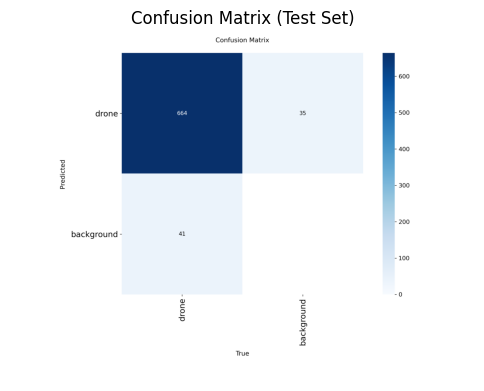

In [8]:
import matplotlib.pyplot as plt
import cv2
import os

# Path to already-generated confusion matrix
cm_path = os.path.join(WORK_DIR, "test_final", "confusion_matrix.png")

if not os.path.exists(cm_path):
    print("⚠️ Confusion matrix not found. Run evaluation cell first.")
else:
    img = cv2.imread(cm_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title("Confusion Matrix (Test Set)")
    plt.axis('off')
    plt.show()

---
## Visual prediction samples

In [9]:
model.predict(
    source="/content/drive/MyDrive/New_Global_Split_v2/test/images",
    conf=0.25,
    iou=0.45,
    max_det=3,
    imgsz=640,
    device=device,
    save=True,
    save_txt=True,
    save_conf=True,
    project=WORK_DIR,
    name="test_predictions_final",
    exist_ok=True,
    verbose=False
)

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/uav_project/test_predictions_final
691 labels saved to /content/uav_project/test_predictions_final/labels


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'drone'}
 obb: None
 orig_img: array([[[220,  79,  58],
         [220,  79,  58],
         [220,  79,  58],
         ...,
         [255, 119,  93],
         [255, 119,  93],
         [255, 119,  93]],
 
        [[222,  79,  58],
         [222,  79,  58],
         [222,  79,  58],
         ...,
         [252, 116,  90],
         [252, 116,  90],
         [252, 116,  90]],
 
        [[222,  77,  56],
         [222,  77,  56],
         [223,  76,  56],
         ...,
         [250, 113,  87],
         [250, 113,  87],
         [250, 113,  87]],
 
        ...,
 
        [[ 68,  84,  83],
         [ 73,  89,  88],
         [ 73,  89,  88],
         ...,
         [ 51,  88,  78],
         [ 64, 101,  91],
         [ 42,  82,  71]],
 
        [[ 71,  87,  86],
         [ 81,  97,  96],
         [ 69,  85,  84],
         ...,
         [ 47,  87,

In [10]:
pred_path = os.path.join(WORK_DIR, "test_predictions_final")
images = glob.glob(f"{pred_path}/*.jpg")

print("Prediction images:", len(images))
samples = random.sample(images, min(20, len(images)))

plt.figure(figsize=(20, 15))

for i, img_path in enumerate(samples):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4, 5, i+1)
    plt.imshow(img)
    plt.title(f"{i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
## Tracking setup control

In [11]:
USE_DRONE = "drone3"  # change to "drone2" when needed

DRONE2_SEQ = "/content/drive/MyDrive/Tracking_Test/drone2_from_split_test"
DRONE3_SEQ = "/content/drive/MyDrive/Tracking_Test/drone3_from_split_test"

if USE_DRONE == "drone2":
    TRACK_SEQ_DIR = DRONE2_SEQ
    TRACKER_OUTPUT_DIR = os.path.join(WORK_DIR, "tracker_output_drone2_final")
    VIDEO_NAME = "tracked_uav_drone2_final.mp4"

elif USE_DRONE == "drone3":
    TRACK_SEQ_DIR = DRONE3_SEQ
    TRACKER_OUTPUT_DIR = os.path.join(WORK_DIR, "tracker_output_drone3_final")
    VIDEO_NAME = "tracked_uav_drone3_final.mp4"

else:
    raise ValueError("USE_DRONE must be 'drone2' or 'drone3'")

print("Tracking:", USE_DRONE)
print("Input:", TRACK_SEQ_DIR)
print("Output:", TRACKER_OUTPUT_DIR)

assert os.path.exists(TRACK_SEQ_DIR), "Tracking sequence folder not found."

Tracking: drone3
Input: /content/drive/MyDrive/Tracking_Test/drone3_from_split_test
Output: /content/uav_project/tracker_output_drone3_final


---
## KalmanUAVTracker

In [12]:
# ─────────────────────────────────────────────────────────────
"""
KalmanUAVTracker
────────────────
State vector : [cx, cy, w, h, vx, vy, vw, vh]  (8-D)

Updates in this version:
• IoU + center-distance association
• cleaner labels
• clipped boxes
• better for small UAVs
"""
# ─────────────────────────────────────────────────────────────

import numpy as np
import cv2
from scipy.optimize import linear_sum_assignment
from ultralytics import YOLO


# ── IoU helper ────────────────────────────────────────────────
def iou_batch(bboxes_a: np.ndarray, bboxes_b: np.ndarray) -> np.ndarray:
    """Vectorised IoU  (N×4, M×4) → N×M  |  format: [cx,cy,w,h]"""
    if len(bboxes_a) == 0 or len(bboxes_b) == 0:
        return np.zeros((len(bboxes_a), len(bboxes_b)), dtype=np.float32)

    ax1 = bboxes_a[:, 0:1] - bboxes_a[:, 2:3] / 2
    ay1 = bboxes_a[:, 1:2] - bboxes_a[:, 3:4] / 2
    ax2 = ax1 + bboxes_a[:, 2:3]
    ay2 = ay1 + bboxes_a[:, 3:4]

    bx1 = bboxes_b[:, 0] - bboxes_b[:, 2] / 2
    by1 = bboxes_b[:, 1] - bboxes_b[:, 3] / 2
    bx2 = bx1 + bboxes_b[:, 2]
    by2 = by1 + bboxes_b[:, 3]

    inter_x1 = np.maximum(ax1, bx1)
    inter_y1 = np.maximum(ay1, by1)
    inter_x2 = np.minimum(ax2, bx2)
    inter_y2 = np.minimum(ay2, by2)

    inter = np.maximum(0, inter_x2 - inter_x1) * np.maximum(0, inter_y2 - inter_y1)
    area_a = bboxes_a[:, 2:3] * bboxes_a[:, 3:4]
    area_b = bboxes_b[:, 2] * bboxes_b[:, 3]
    union = area_a + area_b - inter + 1e-9

    return inter / union


# ── Single Track ──────────────────────────────────────────────
class KalmanTrack:
    """
    Constant-velocity Kalman filter for one UAV bounding box.
    State  : [cx, cy, w, h, vx, vy, vw, vh]
    Measure: [cx, cy, w, h]
    """
    _count = 0

    def __init__(self, bbox: np.ndarray, class_id: int = 0):
        KalmanTrack._count += 1
        self.id = KalmanTrack._count
        self.class_id = class_id
        self.hits = 1
        self.no_update = 0
        self.age = 1
        self.history = []

        dt = 1.0

        # State transition matrix F
        self.F = np.eye(8, dtype=np.float32)
        for i in range(4):
            self.F[i, i + 4] = dt

        # Measurement matrix H
        self.H = np.zeros((4, 8), dtype=np.float32)
        for i in range(4):
            self.H[i, i] = 1.0

        # Process noise Q
        self.Q = np.eye(8, dtype=np.float32)
        self.Q[:4, :4] *= 0.05
        self.Q[4:, 4:] *= 0.01

        # Measurement noise R
        self.R = np.eye(4, dtype=np.float32) * 1.0

        # Error covariance P
        self.P = np.eye(8, dtype=np.float32) * 10.0
        self.P[4:, 4:] *= 100.0

        # Initial state x
        self.x = np.zeros((8, 1), dtype=np.float32)
        self.x[:4, 0] = bbox

    def predict(self) -> np.ndarray:
        """Predict next bbox state."""
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        self.age += 1
        self.no_update += 1
        self.history.append(self.x[:4, 0].copy())
        return self.x[:4, 0]

    def update(self, bbox: np.ndarray):
        """Update with detected bbox."""
        z = bbox.reshape(4, 1).astype(np.float32)

        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y

        I = np.eye(8, dtype=np.float32)
        self.P = (I - K @ self.H) @ self.P

        self.hits += 1
        self.no_update = 0

    @property
    def bbox(self) -> np.ndarray:
        return self.x[:4, 0]

    @property
    def bbox_xyxy(self) -> np.ndarray:
        cx, cy, w, h = self.x[:4, 0]
        return np.array([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2])

    @property
    def velocity(self) -> np.ndarray:
        return self.x[4:6, 0]


# ── Multi-Object Tracker ──────────────────────────────────────
class UAVTracker:
    """
    Multi-object UAV tracker combining:
      • YOLOv8 detection
      • Kalman filter state estimation
      • Hungarian algorithm association
      • IoU + center-distance matching
    """

    def __init__(
        self,
        det_model_path: str,
        conf_threshold: float = 0.30,
        iou_threshold: float = 0.45,
        max_age: int = 40,
        min_hits: int = 4,
        iou_assoc_thr: float = 0.30,
        distance_weight: float = 0.40,
        max_center_dist: float = 80.0,
        device: str = "cuda",
    ):
        self.model = YOLO(det_model_path)
        self.conf = conf_threshold
        self.iou = iou_threshold
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_assoc_thr = iou_assoc_thr
        self.distance_weight = distance_weight
        self.max_center_dist = max_center_dist
        self.device = device

        self.tracks: list[KalmanTrack] = []
        self.frame_count = 0
        KalmanTrack._count = 0

    # ── Run YOLO on a frame
    def _detect(self, frame: np.ndarray) -> np.ndarray:
        """Returns (N, 6): [cx, cy, w, h, conf, class_id]."""
        results = self.model(
            frame,
            conf=self.conf,
            iou=self.iou,
            device=self.device,
            verbose=False
        )[0]

        if results.boxes is None or len(results.boxes) == 0:
            return np.empty((0, 6), dtype=np.float32)

        boxes = results.boxes.xywh.cpu().numpy()
        confs = results.boxes.conf.cpu().numpy().reshape(-1, 1)
        cls_ids = results.boxes.cls.cpu().numpy().reshape(-1, 1)

        return np.hstack([boxes, confs, cls_ids]).astype(np.float32)

    # ── Hungarian assignment
    def _associate(self, tracks: list, detections: np.ndarray):
        if len(tracks) == 0:
            return [], list(range(len(detections))), []

        if len(detections) == 0:
            return [], [], list(range(len(tracks)))

        trk_bboxes = np.array([t.bbox for t in tracks])
        det_bboxes = detections[:, :4]

        # IoU score
        iou_mat = iou_batch(trk_bboxes, det_bboxes)

        # Center-distance score
        trk_centers = trk_bboxes[:, :2]
        det_centers = det_bboxes[:, :2]

        dist_mat = np.linalg.norm(
            trk_centers[:, None, :] - det_centers[None, :, :],
            axis=2
        )

        dist_score = np.clip(1.0 - (dist_mat / self.max_center_dist), 0, 1)

        # Combined score
        iou_weight = 1.0 - self.distance_weight
        score_mat = (iou_weight * iou_mat) + (self.distance_weight * dist_score)

        cost_mat = 1.0 - score_mat
        row_ind, col_ind = linear_sum_assignment(cost_mat)

        matched = []

        for r, c in zip(row_ind, col_ind):
            if score_mat[r, c] >= self.iou_assoc_thr:
                matched.append((r, c))

        matched_trk = {r for r, _ in matched}
        matched_det = {c for _, c in matched}

        unm_trk = [i for i in range(len(tracks)) if i not in matched_trk]
        unm_det = [i for i in range(len(detections)) if i not in matched_det]

        return matched, unm_det, unm_trk

    # ── Main update function
    def update(self, frame: np.ndarray) -> list:
        self.frame_count += 1

        detections = self._detect(frame)

        for t in self.tracks:
            t.predict()

        matched, unm_det, unm_trk = self._associate(self.tracks, detections)

        # Update matched tracks
        for trk_idx, det_idx in matched:
            self.tracks[trk_idx].update(detections[det_idx, :4])
            self.tracks[trk_idx].class_id = int(detections[det_idx, 5])

        # Create new tracks
        for det_idx in unm_det:
            new_trk = KalmanTrack(
                detections[det_idx, :4],
                class_id=int(detections[det_idx, 5])
            )
            self.tracks.append(new_trk)

        # Remove dead tracks
        self.tracks = [t for t in self.tracks if t.no_update <= self.max_age]

        # Return confirmed tracks only
        output = []

        for t in self.tracks:
            if t.hits >= self.min_hits or self.frame_count <= self.min_hits:
                output.append({
                    "id": t.id,
                    "bbox_xyxy": t.bbox_xyxy,
                    "conf": t.hits / (t.age + 1e-9),
                    "class_id": t.class_id,
                    "hits": t.hits,
                    "velocity": t.velocity,
                })

        return output

    def reset(self):
        self.tracks = []
        self.frame_count = 0
        KalmanTrack._count = 0


# ── Colour palette for track IDs ──────────────────────────────
_PALETTE = [
    (0, 255, 0),
    (0, 127, 255),
    (255, 0, 0),
    (255, 200, 0),
    (200, 0, 255),
    (0, 255, 200),
    (255, 100, 100),
    (100, 255, 100),
]

def track_color(tid: int):
    return _PALETTE[tid % len(_PALETTE)]


# ── Draw one frame ────────────────────────────────────────────
def draw_tracks(frame: np.ndarray, tracks: list, class_names: dict) -> np.ndarray:
    vis = frame.copy()
    H, W = vis.shape[:2]

    for t in tracks:
        x1, y1, x2, y2 = t["bbox_xyxy"].astype(int)

        # Clip to frame
        x1 = max(0, min(W - 1, x1))
        y1 = max(0, min(H - 1, y1))
        x2 = max(0, min(W - 1, x2))
        y2 = max(0, min(H - 1, y2))

        tid = t["id"]
        cname = class_names.get(t["class_id"], f"cls{t['class_id']}")
        color = track_color(tid)

        # Cleaner label
        label = f"ID:{tid} {cname}"

        cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)

        (tw, th), _ = cv2.getTextSize(
            label,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            1
        )

        label_y1 = max(0, y1 - th - 8)
        label_y2 = max(th + 8, y1)

        cv2.rectangle(
            vis,
            (x1, label_y1),
            (min(W - 1, x1 + tw + 4), label_y2),
            color,
            -1
        )

        cv2.putText(
            vis,
            label,
            (x1 + 2, label_y2 - 4),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (0, 0, 0),
            1,
            cv2.LINE_AA
        )

    return vis

---
## Run Tracker on Test Images

In [13]:
if os.path.exists(TRACKER_OUTPUT_DIR):
    shutil.rmtree(TRACKER_OUTPUT_DIR)
os.makedirs(TRACKER_OUTPUT_DIR, exist_ok=True)

def natural_key(path):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split(r"(\d+)", os.path.basename(path))]

frame_list = sorted(
    glob.glob(os.path.join(TRACK_SEQ_DIR, "*.jpg")) +
    glob.glob(os.path.join(TRACK_SEQ_DIR, "*.jpeg")) +
    glob.glob(os.path.join(TRACK_SEQ_DIR, "*.png")),
    key=natural_key
)

print("Total frames:", len(frame_list))
assert len(frame_list) > 0, "No tracking frames found."

tracker = UAVTracker(
    det_model_path=BEST_PT,
    conf_threshold=0.38,
    iou_threshold=0.45,
    max_age=40,
    min_hits=5,
    iou_assoc_thr=0.30,
    distance_weight=0.40,
    max_center_dist=80.0,
    device=device,
)

track_stats = defaultdict(list)

for processed, img_path in enumerate(frame_list):
    frame = cv2.imread(img_path)

    if frame is None:
        continue

    tracks = tracker.update(frame)

    for t in tracks:
        track_stats[t["id"]].append(t["bbox_xyxy"].copy())

    vis = draw_tracks(frame, tracks, CLASS_NAMES)

    out_path = os.path.join(TRACKER_OUTPUT_DIR, f"frame_{processed:05d}.jpg")
    cv2.imwrite(out_path, vis)

    if processed % 50 == 0:
        print(f"Processed {processed} | active tracks: {len(tracks)}")

print("\n Tracking complete")
print("Frames processed:", len(frame_list))
print("Unique tracks created:", KalmanTrack._count)
print("Stable tracks:", len(track_stats))

Total frames: 249
Processed 0 | active tracks: 0
Processed 50 | active tracks: 0
Processed 100 | active tracks: 0
Processed 150 | active tracks: 0
Processed 200 | active tracks: 1

 Tracking complete
Frames processed: 249
Unique tracks created: 1
Stable tracks: 1


---
## Trajectory Visualization

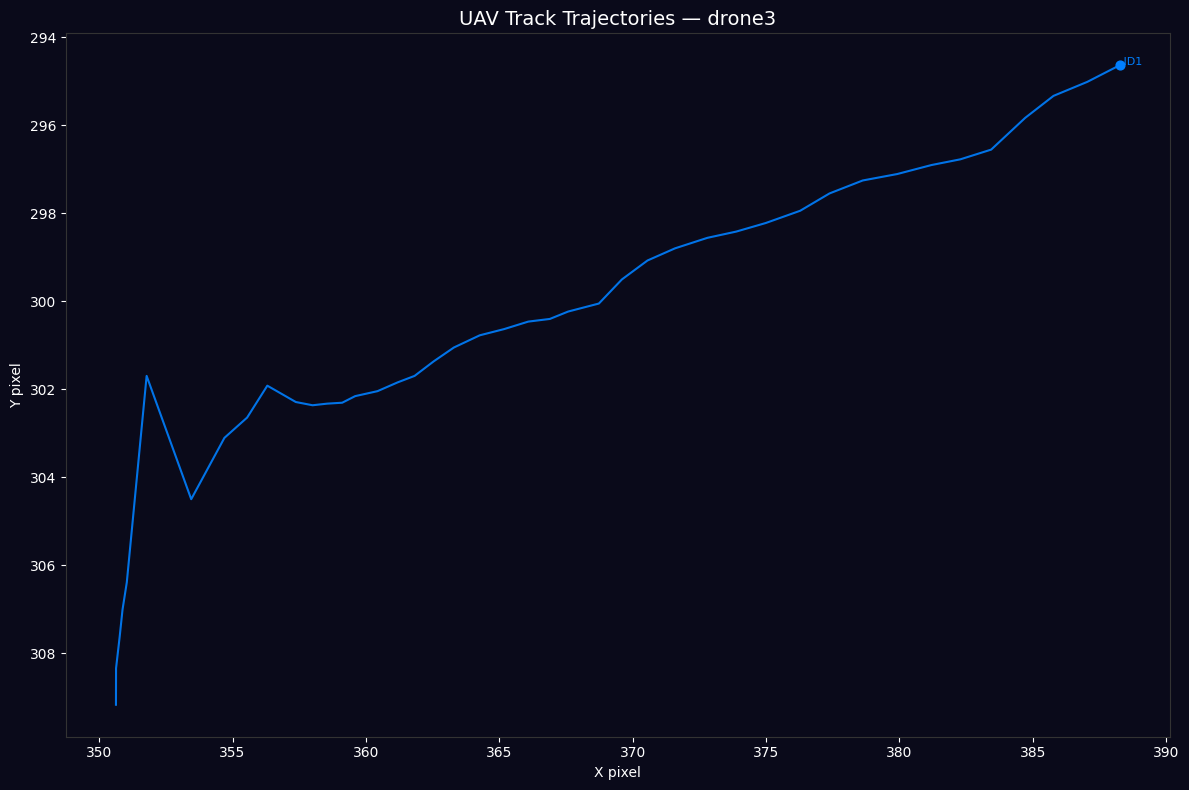

Trajectory saved: /content/uav_project/trajectories_drone3.png


In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_facecolor("#0a0a1a")
fig.patch.set_facecolor("#0a0a1a")
ax.set_title(f"UAV Track Trajectories — {USE_DRONE}", color="white", fontsize=14)
ax.invert_yaxis()

for tid, bboxes in track_stats.items():
    if len(bboxes) < 3:
        continue

    bboxes = np.array(bboxes)
    cx = (bboxes[:, 0] + bboxes[:, 2]) / 2
    cy = (bboxes[:, 1] + bboxes[:, 3]) / 2

    c = np.array(track_color(tid)) / 255.0

    ax.plot(cx, cy, "-", color=c, linewidth=1.5, alpha=0.9)
    ax.scatter(cx[-1], cy[-1], color=c, s=40)
    ax.text(cx[-1], cy[-1], f" ID{tid}", color=c, fontsize=8)

ax.set_xlabel("X pixel", color="white")
ax.set_ylabel("Y pixel", color="white")
ax.tick_params(colors="white")

for spine in ax.spines.values():
    spine.set_edgecolor("#333")

traj_path = os.path.join(WORK_DIR, f"trajectories_{USE_DRONE}.png")
plt.tight_layout()
plt.savefig(traj_path, dpi=150, facecolor="#0a0a1a")
plt.show()

print("Trajectory saved:", traj_path)

---
## Export Tracking Video

In [15]:
frames_for_video = sorted(
    glob.glob(os.path.join(TRACKER_OUTPUT_DIR, "*.jpg")),
    key=natural_key
)

print("Frames for video:", len(frames_for_video))
assert len(frames_for_video) > 0, "No tracking frames found."

sample = cv2.imread(frames_for_video[0])
h, w = sample.shape[:2]

OUTPUT_VIDEO = os.path.join(WORK_DIR, VIDEO_NAME)

writer = cv2.VideoWriter(
    OUTPUT_VIDEO,
    cv2.VideoWriter_fourcc(*"mp4v"),
    30,
    (w, h)
)

for fp in frames_for_video:
    frame = cv2.imread(fp)
    if frame is not None:
        writer.write(frame)

writer.release()

print("Video saved:", OUTPUT_VIDEO)
display(Video(OUTPUT_VIDEO, embed=True, width=700))

Output hidden; open in https://colab.research.google.com to view.

---
## Quick-Start: Real-time Inference on a Single Image

In [16]:
# ─────────────────────────────────────────────
from IPython.display import Image as IPImage
import cv2, os

def infer_single_image(img_path: str):
    """Run detection on a single image using the already loaded model."""

    frame = cv2.imread(img_path)

    if frame is None:
        print(f"Cannot read: {img_path}")
        return

    # Use already loaded model (DO NOT reload)
    results = model(frame, conf=0.35, verbose=False)[0]

    vis = results.plot()

    out_path = os.path.join(WORK_DIR, "single_infer.jpg")
    cv2.imwrite(out_path, vis)

    print(f"Saved: {out_path}")

    return IPImage(filename=out_path, width=700)

Results saved to /content/uav_project/test_predictions_final
692 labels saved to /content/uav_project/test_predictions_final/labels
Saved: /content/uav_project/single_infer.jpg


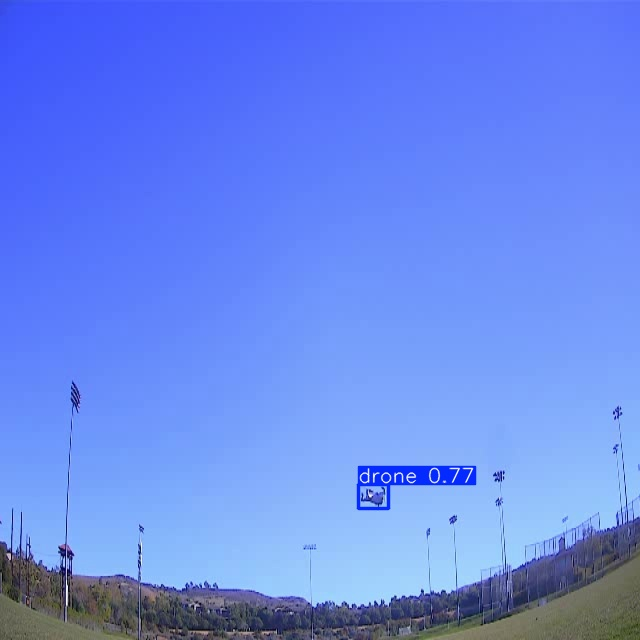

In [17]:
import glob

sample_img = sorted(
    glob.glob("/content/drive/MyDrive/New_Global_Split_v2/test/images/*.jpg")
)[0]

infer_single_image(sample_img)

---
## Test the Pipeline on a new video

In [18]:
from ultralytics import YOLO
import os

VIDEO_PATH = "/content/drone4_test_video.mp4"

OUTPUT_DIR = os.path.join(WORK_DIR, "unseen_video_test")

model.predict(
    source=VIDEO_PATH,
    conf=0.45,
    iou=0.45,
    imgsz=640,
    device=device,
    save=True,
    project=WORK_DIR,
    name="unseen_video_clean",
    exist_ok=True,
    verbose=False
)

print("Unseen video inference done")

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/uav_project/unseen_video_clean
267 labels saved to /content/uav_project/unseen_video_clean/labels
Unseen video inference done


In [21]:
!ffmpeg -i /content/uav_project/unseen_video_clean/drone4_test_video.avi \
        /content/uav_project/unseen_video_clean/drone4_test_video.mp4 -y

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [22]:
display(Video("/content/uav_project/unseen_video_clean/drone4_test_video.mp4", width=700))